# MyPortfolioManagement - Interactive Tutorial

This notebook demonstrates all the key features of the myPortfolioManagement library.

**Contents:**
1. Data Fetching
2. Returns Calculation
3. Portfolio Optimization
4. Performance Metrics
5. Backtesting
6. Clustering
7. Visualization

In [3]:
# Setup
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from myPortfolioManagement.myReturns import (
    calculate_returns,
    average_returns,
    get_benchmark_returns
)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Data Fetching

Fetch historical price data using Yahoo Finance.

In [4]:
from myPortfolioManagement.myData import get_stock_prices, get_stock_info

# Define tickers - diversified ETF portfolio
tickers = [
    'SPY',   # S&P 500
    'QQQ',   # Nasdaq 100
    'IWM',   # Small Cap
    'EFA',   # International
    'EEM',   # Emerging Markets
    'AGG',   # Bonds
    'TIP',   # TIPS
    'GLD',   # Gold
    'VNQ',   # Real Estate
]

# Fetch data
prices = get_stock_prices(
    yahoo_tickers=tickers,
    start_date='2018-01-01',
    wide_format=True
)

print(f"Data shape: {prices.shape}")
print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
prices.head()

100%|██████████| 9/9 [00:01<00:00,  5.59it/s]


get_stock_prices took 4.859sec
Data shape: (2004, 9)
Date range: 2018-01-02 00:00:00 to 2025-12-19 00:00:00


longname,Invesco QQQ Trust,SPDR Gold Shares,SPDR S&P 500 ETF,Vanguard Real Estate Index Fund ETF Shares,iShares Core U.S. Aggregate Bond ETF,iShares MSCI EAFE ETF,iShares MSCI Emerging Markets ETF,iShares Russell 2000 ETF,iShares TIPS Bond ETF
Date,,,,,,,,,
2018-01-02,150.6054,125.1500,237.2082,61.3691,86.9814,55.6033,39.9833,139.1315,88.6666
2018-01-03,152.0687,124.8200,238.7086,61.1909,86.9894,55.8702,40.3664,139.2761,88.7522
2018-01-04,152.3348,125.4600,239.7147,60.1368,86.9335,56.4826,40.5663,139.6467,88.7756
2018-01-05,153.8647,125.3300,241.3122,60.1665,86.8779,56.7966,40.9160,139.9361,88.7600
2018-01-08,154.4634,125.3100,241.7535,60.4783,86.8539,56.7809,40.9160,140.1530,88.6666


In [5]:
# Get stock information
stock_info = get_stock_info(tickers)
stock_info[['yahooTicker', 'longName', 'sector', 'currency']]

100%|██████████| 9/9 [00:01<00:00,  6.50it/s]


,yahooTicker,longName,sector,currency
0,SPY,SPDR S&P 500 ETF,Other,USD
1,QQQ,Invesco QQQ Trust,Other,USD
2,IWM,iShares Russell 2000 ETF,Other,USD
3,EFA,iShares MSCI EAFE ETF,Other,USD
4,EEM,iShares MSCI Emerging Markets ETF,Other,USD
5,AGG,iShares Core U.S. Aggregate Bond ETF,Other,USD
6,TIP,iShares TIPS Bond ETF,Other,USD
7,GLD,SPDR Gold Shares,Other,USD
8,VNQ,Vanguard Real Estate Index Fund ETF Shares,Other,USD


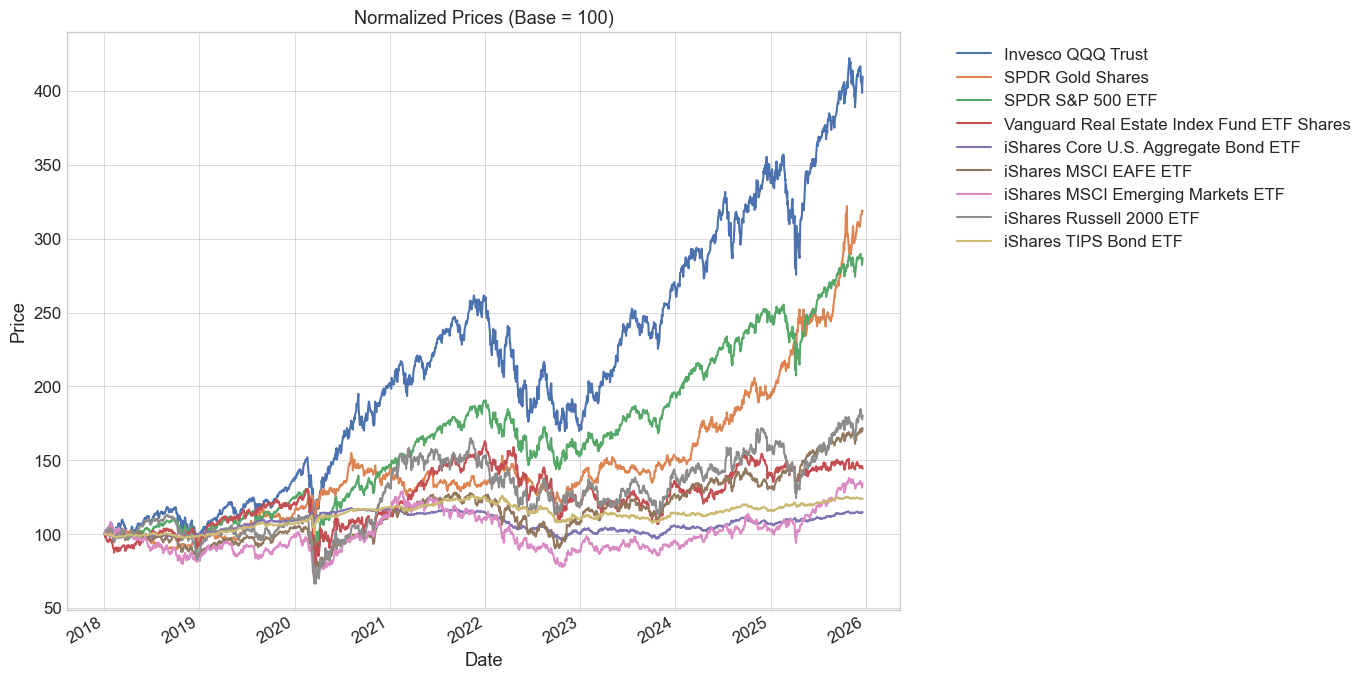

In [6]:
# Plot normalized prices
normalized = prices / prices.iloc[0] * 100
normalized.plot(figsize=(14, 7), title='Normalized Prices (Base = 100)')
plt.ylabel('Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Returns Calculation

In [7]:
# Daily returns
returns = calculate_returns(prices, log_returns=False)
print("Daily Returns Statistics:")
returns.describe().T[['mean', 'std', 'min', 'max']]

Daily Returns Statistics:


,mean,std,min,max
longname,,,,
Invesco QQQ Trust,0.0008,0.0152,-0.1198,0.1200
SPDR Gold Shares,0.0006,0.0095,-0.0643,0.0485
SPDR S&P 500 ETF,0.0006,0.0123,-0.1094,0.1050
Vanguard Real Estate Index Fund ETF Shares,0.0003,0.0140,-0.1773,0.0900
iShares Core U.S. Aggregate Bond ETF,0.0001,0.0037,-0.0400,0.0237
iShares MSCI EAFE ETF,0.0003,0.0113,-0.1099,0.0847
iShares MSCI Emerging Markets ETF,0.0002,0.0132,-0.1248,0.0805
iShares Russell 2000 ETF,0.0004,0.0155,-0.1327,0.0915
iShares TIPS Bond ETF,0.0001,0.0039,-0.0287,0.0445


In [8]:
# Monthly returns
returns_monthly = calculate_returns(prices, convert_to='monthly')
print("Monthly Returns (last 12 months):")
returns_monthly.tail(12)

Monthly Returns (last 12 months):


longname,Invesco QQQ Trust,SPDR Gold Shares,SPDR S&P 500 ETF,Vanguard Real Estate Index Fund ETF Shares,iShares Core U.S. Aggregate Bond ETF,iShares MSCI EAFE ETF,iShares MSCI Emerging Markets ETF,iShares Russell 2000 ETF,iShares TIPS Bond ETF
Date,,,,,,,,,
2025-01-31,0.0216,0.0679,0.0269,0.0165,0.0052,0.0480,0.0215,0.0250,0.0137
2025-02-28,-0.0270,0.0182,-0.0127,0.0370,0.0224,0.0295,0.0115,-0.0522,0.0216
2025-03-31,-0.0759,0.0945,-0.0557,-0.0259,-0.0003,0.0018,0.0113,-0.0685,0.0068
2025-04-30,0.0140,0.0542,-0.0087,-0.0244,0.0043,0.0370,0.0014,-0.0232,0.0013
2025-05-31,0.0918,-0.0006,0.0628,0.0112,-0.0061,0.0479,0.0402,0.0524,-0.0063
2025-06-30,0.0639,0.0041,0.0514,0.0069,0.0146,0.0240,0.0700,0.0552,0.0094
2025-07-31,0.0242,-0.0061,0.0230,0.0009,-0.0026,-0.0209,0.0066,0.0167,0.0001
2025-08-31,0.0095,0.0499,0.0205,0.0348,0.0119,0.0452,0.0268,0.0719,0.0161
2025-09-30,0.0538,0.1176,0.0356,0.0006,0.0113,0.0207,0.0710,0.0318,0.0042


In [9]:
# Expected returns (different methods)
mu_hist = average_returns(returns, method='hist', periods=252)
mu_ema = average_returns(returns, method='ema', span=500, periods=252)

expected_returns = pd.DataFrame({
    'Historical': mu_hist,
    'EMA': mu_ema
}).sort_values('Historical', ascending=False)

print("Expected Annual Returns:")
expected_returns.round(4)

Expected Annual Returns:


,Historical,EMA
longname,,
Invesco QQQ Trust,0.1941,0.2745
SPDR Gold Shares,0.1571,0.4927
SPDR S&P 500 ETF,0.1418,0.2201
iShares Russell 2000 ETF,0.0769,0.2033
iShares MSCI EAFE ETF,0.0704,0.2025
Vanguard Real Estate Index Fund ETF Shares,0.0473,0.0421
iShares MSCI Emerging Markets ETF,0.0379,0.2174
iShares TIPS Bond ETF,0.0274,0.0405
iShares Core U.S. Aggregate Bond ETF,0.0175,0.0505


In [10]:
# Get benchmark
benchmark = get_benchmark_returns('S&P500')
print(f"Benchmark shape: {benchmark.shape}")
benchmark.tail()
benchmark

[*********************100%***********************]  1 of 1 completed

Benchmark shape: (24610, 1)


,S&P500
Date,
1927-12-30,NaN
1928-01-03,0.0057
1928-01-04,-0.0023
1928-01-05,-0.0096
1928-01-06,0.0063
...,...
2025-12-15,-0.0016
2025-12-16,-0.0024
2025-12-17,-0.0116


## 3. Portfolio Optimization

In [11]:
from myPortfolioManagement.myPortfolioOptimisation import (
    HRP,
    equal_weight_portfolio,
    inverse_vol_portfolio,
    port_GMV,
    port_max_sharpe,
    port_CVAR,
    generate_rp_portfolios
)

returns_opt = returns.fillna(0)

In [12]:
# Equal Weight
w_equal = equal_weight_portfolio(returns_opt)
print("Equal Weight Portfolio:")
w_equal

Equal Weight Portfolio:


,port_naive
asset,
Invesco QQQ Trust,0.1111
SPDR Gold Shares,0.1111
SPDR S&P 500 ETF,0.1111
Vanguard Real Estate Index Fund ETF Shares,0.1111
iShares Core U.S. Aggregate Bond ETF,0.1111
iShares MSCI EAFE ETF,0.1111
iShares MSCI Emerging Markets ETF,0.1111
iShares Russell 2000 ETF,0.1111
iShares TIPS Bond ETF,0.1111


In [13]:
# Inverse Volatility
w_inv_vol = inverse_vol_portfolio(returns_opt, weight_max=0.25)
print("Inverse Volatility Portfolio:")
w_inv_vol.sort_values('port_inverse_vol', ascending=False)

Inverse Volatility Portfolio:


,port_inverse_vol
asset,
iShares Core U.S. Aggregate Bond ETF,0.2500
iShares TIPS Bond ETF,0.2391
SPDR Gold Shares,0.0976
iShares MSCI EAFE ETF,0.0815
SPDR S&P 500 ETF,0.0753
iShares MSCI Emerging Markets ETF,0.0700
Vanguard Real Estate Index Fund ETF Shares,0.0659
Invesco QQQ Trust,0.0609
iShares Russell 2000 ETF,0.0596


In [14]:
# Hierarchical Risk Parity (HRP)
w_hrp = HRP(
    model='HRP',
    returns_training=returns_opt,
    codependence='pearson',
    rm='MV',
    weight_max=0.25,
    weight_min=0.02
)
print("HRP Portfolio:")
w_hrp.sort_values('port_weight', ascending=False)

HRP Portfolio:


,port_weight
asset,
SPDR Gold Shares,0.2500
iShares Core U.S. Aggregate Bond ETF,0.2500
iShares TIPS Bond ETF,0.2500
SPDR S&P 500 ETF,0.1004
Invesco QQQ Trust,0.0657
iShares MSCI Emerging Markets ETF,0.0224
iShares MSCI EAFE ETF,0.0214
iShares Russell 2000 ETF,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200


In [15]:
# HERC (Hierarchical Equal Risk Contribution)
w_herc = HRP(
    model='HERC',
    returns_training=returns_opt,
    rm='CVaR',
    weight_max=0.30,
    weight_min=0.02
)
print("HERC Portfolio:")
w_herc.sort_values('port_weight', ascending=False)

HERC Portfolio:


,port_weight
asset,
iShares Core U.S. Aggregate Bond ETF,0.2500
iShares TIPS Bond ETF,0.2388
SPDR Gold Shares,0.1854
Vanguard Real Estate Index Fund ETF Shares,0.1522
iShares MSCI EAFE ETF,0.0411
SPDR S&P 500 ETF,0.0362
iShares MSCI Emerging Markets ETF,0.0360
iShares Russell 2000 ETF,0.0303
Invesco QQQ Trust,0.0301


In [16]:
# Global Minimum Variance
w_gmv = port_GMV(returns_opt, weight_min=0.02, weight_max=0.30)
print("Global Minimum Variance Portfolio:")
w_gmv.sort_values('port_min_vol', ascending=False)

Global Minimum Variance Portfolio:


,port_min_vol
asset,
iShares Core U.S. Aggregate Bond ETF,0.3000
iShares TIPS Bond ETF,0.3000
SPDR Gold Shares,0.2253
SPDR S&P 500 ETF,0.0747
Invesco QQQ Trust,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200
iShares MSCI EAFE ETF,0.0200
iShares MSCI Emerging Markets ETF,0.0200
iShares Russell 2000 ETF,0.0200


In [17]:
# Maximum Sharpe Ratio
w_sharpe = port_max_sharpe(returns_opt, rf=0.04, weight_min=0.02, weight_max=0.30)
print("Max Sharpe Portfolio:")
w_sharpe.sort_values('port_max_Sharpe', ascending=False)

Max Sharpe Portfolio:


,port_max_Sharpe
asset,
Invesco QQQ Trust,0.3000
SPDR Gold Shares,0.3000
iShares TIPS Bond ETF,0.2800
SPDR S&P 500 ETF,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200
iShares Core U.S. Aggregate Bond ETF,0.0200
iShares MSCI EAFE ETF,0.0200
iShares MSCI Emerging Markets ETF,0.0200
iShares Russell 2000 ETF,0.0200


In [18]:
# Minimum CVaR
w_cvar = port_CVAR(returns_opt, confidence_interval=0.95, rf=0.04, weight_min=0.02, weight_max=0.30)
print("Minimum CVaR Portfolio:")
w_cvar.sort_values('port_target_CVAR', ascending=False)

Minimum CVaR Portfolio:


,port_target_CVAR
asset,
iShares Core U.S. Aggregate Bond ETF,0.3000
iShares TIPS Bond ETF,0.3000
SPDR Gold Shares,0.2362
SPDR S&P 500 ETF,0.0555
iShares MSCI EAFE ETF,0.0283
Invesco QQQ Trust,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200
iShares MSCI Emerging Markets ETF,0.0200
iShares Russell 2000 ETF,0.0200


In [19]:
# Compare all portfolios - all functions now return DataFrames with 'asset' as index
all_weights = pd.DataFrame({
    'Equal': w_equal['port_naive'],
    'Inv_Vol': w_inv_vol['port_inverse_vol'],
    'HRP': w_hrp['port_weight'],
    'HERC': w_herc['port_weight'],
    'GMV': w_gmv['port_min_vol'],
    'Max_Sharpe': w_sharpe['port_max_Sharpe'],
    'Min_CVaR': w_cvar['port_target_CVAR']
})

# Validate weights sum to 1
print("Weights sum check:")
print(all_weights.sum().round(4))
print("\nAll Portfolio Weights Comparison:")
all_weights.round(3)

Weights sum check:
Equal        1.0000
Inv_Vol      1.0000
HRP          1.0000
HERC         1.0001
GMV          1.0000
Max_Sharpe   1.0000
Min_CVaR     1.0000
dtype: float64

All Portfolio Weights Comparison:


,Equal,Inv_Vol,HRP,HERC,GMV,Max_Sharpe,Min_CVaR
asset,,,,,,,
Invesco QQQ Trust,0.1110,0.0610,0.0660,0.0300,0.0200,0.3000,0.0200
SPDR Gold Shares,0.1110,0.0980,0.2500,0.1850,0.2250,0.3000,0.2360
SPDR S&P 500 ETF,0.1110,0.0750,0.1000,0.0360,0.0750,0.0200,0.0550
Vanguard Real Estate Index Fund ETF Shares,0.1110,0.0660,0.0200,0.1520,0.0200,0.0200,0.0200
iShares Core U.S. Aggregate Bond ETF,0.1110,0.2500,0.2500,0.2500,0.3000,0.0200,0.3000
iShares MSCI EAFE ETF,0.1110,0.0820,0.0210,0.0410,0.0200,0.0200,0.0280
iShares MSCI Emerging Markets ETF,0.1110,0.0700,0.0220,0.0360,0.0200,0.0200,0.0200
iShares Russell 2000 ETF,0.1110,0.0600,0.0200,0.0300,0.0200,0.0200,0.0200
iShares TIPS Bond ETF,0.1110,0.2390,0.2500,0.2390,0.3000,0.2800,0.3000


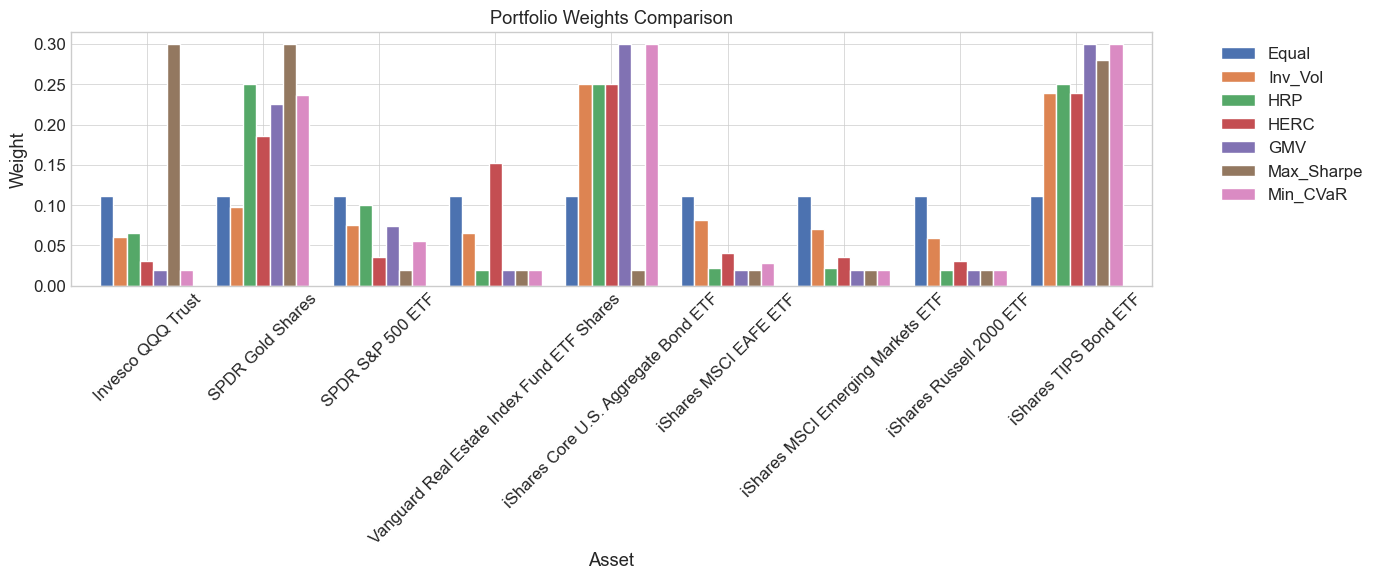

In [20]:
# Visualize weights
all_weights.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.title('Portfolio Weights Comparison')
plt.xlabel('Asset')
plt.ylabel('Weight')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Performance Metrics

In [21]:
from myPortfolioManagement.myPerformanceMetrics import (
    get_main_stats,
    alpha_beta_table,
    drawdown_details,
    performance_overview,
    cagr
)
from myPortfolioManagement.myUtils import balance_dates

In [22]:
# Main performance stats
stats = get_main_stats(returns, rf=0.04)
print("Main Performance Statistics:")
stats.round(4)

get_main_stats took 700.77ms
Main Performance Statistics:


,total_ret,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
Invesco QQQ Trust,3.0971,0.1937,0.7873,0.7883,0.5516,-0.3512
SPDR Gold Shares,2.1883,0.1567,0.9319,0.9155,0.7123,-0.2200
SPDR S&P 500 ETF,1.8692,0.1415,0.6684,0.6765,0.4197,-0.3372
Vanguard Real Estate Index Fund ETF Shares,0.4436,0.0472,0.2018,0.2100,0.1113,-0.4240
iShares Core U.S. Aggregate Bond ETF,0.1478,0.0175,-0.1392,-0.1457,0.0947,-0.1843
iShares MSCI EAFE ETF,0.7168,0.0702,0.3264,0.3364,0.2053,-0.3419
iShares MSCI Emerging Markets ETF,0.3436,0.0378,0.1581,0.1623,0.0949,-0.3982
iShares Russell 2000 ETF,0.8025,0.0768,0.3283,0.3332,0.1867,-0.4113
iShares TIPS Bond ETF,0.2399,0.0274,0.0323,0.0321,0.1886,-0.1451


In [23]:
# CAGR
cagr_values = cagr(prices)
print("Compound Annual Growth Rate:")
cagr_values.sort_values(ascending=False).round(4)

Compound Annual Growth Rate:


Invesco QQQ Trust                            0.1938
SPDR Gold Shares                             0.1568
SPDR S&P 500 ETF                             0.1416
iShares Russell 2000 ETF                     0.0768
iShares MSCI EAFE ETF                        0.0702
Vanguard Real Estate Index Fund ETF Shares   0.0472
iShares MSCI Emerging Markets ETF            0.0378
iShares TIPS Bond ETF                        0.0274
iShares Core U.S. Aggregate Bond ETF         0.0175
dtype: float64

In [24]:
# Alpha-Beta analysis
ab = alpha_beta_table(returns, benchmark, rf=0.04)
print("Alpha-Beta Analysis (Full, Bull, Bear markets):")
ab

Alpha-Beta Analysis (Full, Bull, Bear markets):


,alpha,alpha_bull,alpha_bear,beta,beta_bull,beta_bear
asset,,,,,,
Invesco QQQ Trust,3.7500,1.2500,0.2000,1.1500,1.1100,1.0900
SPDR Gold Shares,-1.0000,-0.9900,-0.9900,0.0700,0.1000,0.0600
SPDR S&P 500 ETF,-0.0700,-0.0300,-0.0500,0.9900,0.9900,0.9900
Vanguard Real Estate Index Fund ETF Shares,-0.7900,-0.6100,0.1300,0.8500,0.8600,0.9500
iShares Core U.S. Aggregate Bond ETF,-1.0000,-0.9900,-0.9900,0.0400,0.0400,0.0300
iShares MSCI EAFE ETF,-0.8900,-0.6900,-0.6100,0.7900,0.7600,0.8100
iShares MSCI Emerging Markets ETF,-0.8600,-0.6800,-0.6000,0.8100,0.7600,0.8300
iShares Russell 2000 ETF,1.3400,0.3000,0.3200,1.0900,1.0100,1.0900
iShares TIPS Bond ETF,-1.0000,-0.9900,-0.9900,0.0200,0.0100,0.0100


In [25]:
# Drawdown details
spy_prices = prices.iloc[:, 0]
dd = drawdown_details(spy_prices, top_drawdowns=5)
print(f"Top 5 Drawdowns for {prices.columns[0]}:")
dd

Top 5 Drawdowns for Invesco QQQ Trust:


,start,valley,end,days,Years,max drawdown,Peak Price,Bottom Price
71,2021-12-28,2022-11-03,2023-12-12,715,2,-35.0000,392.0000,256.0000
35,2020-02-20,2020-03-16,2020-06-02,104,0,-29.0000,227.0000,164.0000
93,2025-02-20,2025-04-08,2025-06-23,124,0,-23.0000,535.0000,415.0000
12,2018-08-30,2018-12-24,2019-04-11,225,1,-23.0000,178.0000,138.0000
87,2024-07-11,2024-08-07,2024-11-05,118,0,-14.0000,489.0000,432.0000


## 5. Backtesting

In [26]:
from myPortfolioManagement.myBacktesting import (
    bootstrap_stats,
    bootstrap_portfolio_performance,
    beating_probability
)

# Create portfolio returns
hrp_weights = w_hrp['port_weight'].to_dict()
portfolio_returns = (returns * pd.Series(hrp_weights)).sum(axis=1)
portfolio_returns.name = 'HRP_Portfolio'

In [29]:
# Bootstrap statistics
bootstrap_results = bootstrap_stats(
    returns=portfolio_returns,
    returns_benchmark=benchmark.squeeze(),
    rf=0.04,
    n_sim=500
)
print("Bootstrap Statistics:")
bootstrap_results.describe().round(4)

bootstrap_stats took 61.454sec
Bootstrap Statistics:


,cagr,volatility,sharpe,adjusted_sortino,alpha,beta
count,440.0000,440.0000,440.0000,440.0000,440.0000,440.0000
mean,0.0213,0.0792,0.6001,0.6052,-0.9993,0.2814
std,0.3153,0.0019,0.2352,0.2559,0.0001,0.0079
min,-0.5811,0.0755,0.1384,0.1067,-0.9994,0.2659
25%,-0.1985,0.0776,0.4397,0.4019,-0.9994,0.2753
50%,-0.0679,0.0793,0.5912,0.5994,-0.9993,0.2813
75%,0.2206,0.0806,0.7951,0.8129,-0.9993,0.2871
max,0.9148,0.0831,1.0858,1.1186,-0.9992,0.2972


In [31]:
from myPortfolioManagement.myBacktesting import (
    bootstrap_stats,
    bootstrap_portfolio_performance,
    beating_probability
)

In [32]:
# Bootstrap with in-sample/out-of-sample
means, dists, dist_stats = bootstrap_portfolio_performance(
    returns=portfolio_returns,
    returns_benchmark=benchmark.squeeze(),
    out_of_sample_date='2023-01-01',
    n_sim=500
)
print("Bootstrap Performance Metrics:")
means.round(4)

bootstrap_stats took 62.521sec
bootstrap_stats took 60.799sec
bootstrap_stats took 62.043sec
bootstrap_portfolio_performance took 185.450sec
Bootstrap Performance Metrics:


,in_sample,out_of_sample,all_sample
cagr,0.0420,0.2639,0.0470
volatility,0.0822,0.0734,0.0792
sharpe,0.3499,1.7533,0.8579
adjusted_sortino,0.3158,1.9658,0.8545
alpha,-0.9738,-0.9692,-0.9725
beta,0.2778,0.2941,0.2819


In [33]:
# Probability of beating benchmark
beat_prob = beating_probability(
    returns=pd.DataFrame(portfolio_returns),
    returns_benchmark=benchmark,
    n_sample=500
)
print(f"Probability of beating S&P 500: {beat_prob.values[0][0]:.1%}")

Probability of beating S&P 500: 48.0%


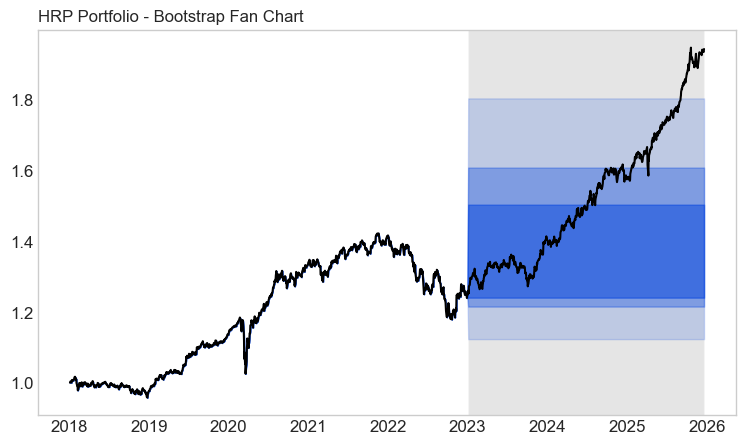

In [27]:
# Fan Chart - Bootstrap simulation of possible portfolio paths
# Shows confidence intervals for future cumulative returns
from myPortfolioManagement.myBacktesting import fan_chart

fan_chart(
    returns=portfolio_returns,
    out_of_sample_date='2023-01-01',
    n_sample=1000,
    starting_value=1,
    chart_title='HRP Portfolio - Bootstrap Fan Chart'
)

## 6. Clustering

In [1]:
from myPortfolioManagement.myClustering import (
    ts_clustering,
    cluster_ftca
)

In [4]:
# Time series clustering
clusters, centers = ts_clustering(
    df=prices,
    number_of_clusters=3,
    algo='dtw',
    plot_bar_center=False
)
print("Asset Clusters:")
clusters

Asset Clusters:


,Cluster
asset,
Invesco QQQ Trust,1
SPDR Gold Shares,1
SPDR S&P 500 ETF,1
iShares MSCI EAFE ETF,1
iShares Russell 2000 ETF,1
Vanguard Real Estate Index Fund ETF Shares,2
iShares Core U.S. Aggregate Bond ETF,2
iShares TIPS Bond ETF,2
iShares MSCI Emerging Markets ETF,3


In [7]:
# FTCA Clustering
ftca = cluster_ftca(returns, threshold=0.5)
print("FTCA Clusters:")
ftca

FTCA Clusters:


,cluster,stock
0,1,iShares MSCI EAFE ETF
1,1,Invesco QQQ Trust
2,1,SPDR S&P 500 ETF
3,1,Vanguard Real Estate Index Fund ETF Shares
4,1,iShares MSCI Emerging Markets ETF
5,1,iShares Russell 2000 ETF
6,2,SPDR Gold Shares
7,3,iShares Core U.S. Aggregate Bond ETF
8,3,iShares TIPS Bond ETF


## 7. Visualization

In [8]:
from myPortfolioManagement.myPlots import (
    correlation_matrix,
    monthly_heatmap
)

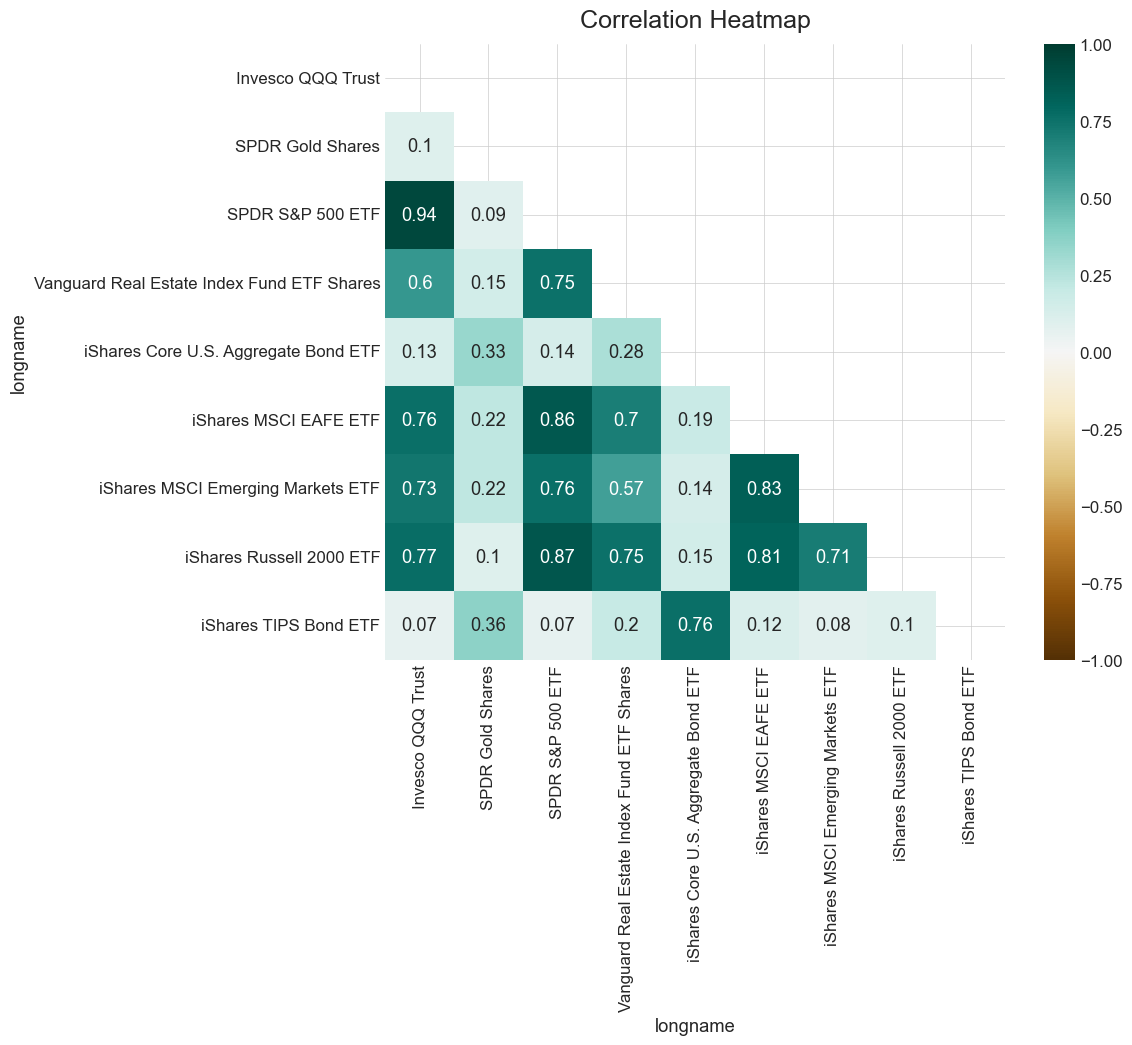

In [9]:
# Correlation matrix
correlation_matrix(returns, figsize=(10, 8))

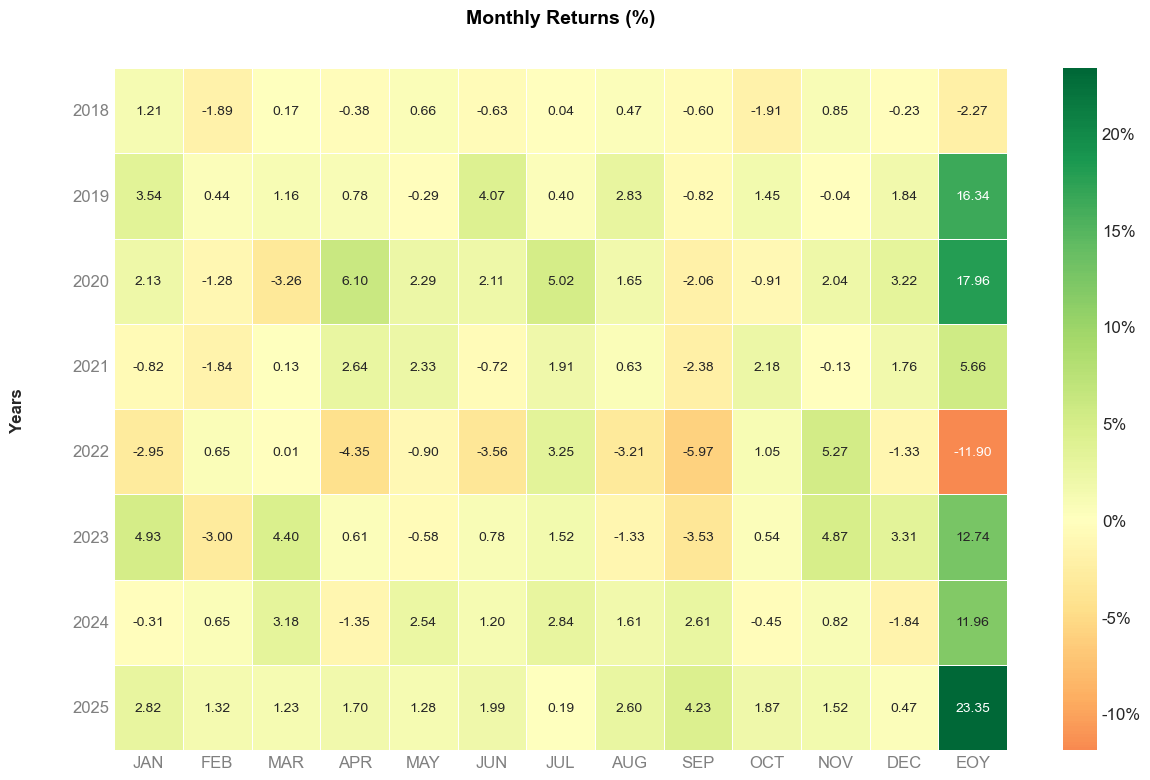

In [34]:
# Monthly heatmap
monthly_heatmap(portfolio_returns, figsize=(12, 8))

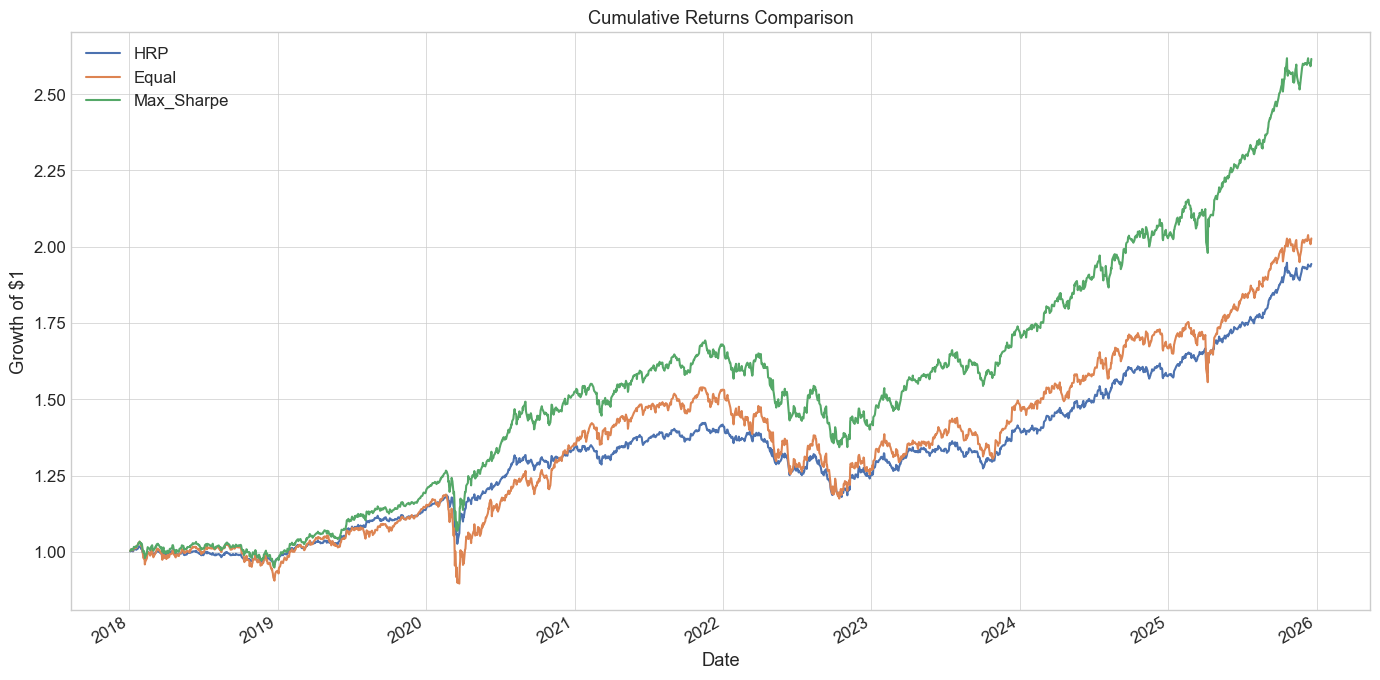

In [35]:
# Portfolio cumulative returns comparison
portfolios = pd.DataFrame({
    'HRP': (returns * pd.Series(w_hrp['port_weight'].to_dict())).sum(axis=1),
    'Equal': (returns * pd.Series(w_equal['port_naive'].to_dict())).sum(axis=1),
    'Max_Sharpe': (returns * pd.Series(w_sharpe['port_max_Sharpe'].to_dict())).sum(axis=1)
})

cumulative = (1 + portfolios).cumprod()
cumulative.plot(figsize=(14, 7), title='Cumulative Returns Comparison')
plt.ylabel('Growth of $1')
plt.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **Data Fetching**: `get_stock_prices()`, `get_stock_info()`
2. **Returns**: `calculate_returns()`, `average_returns()`
3. **Optimization**: `HRP()`, `port_GMV()`, `port_max_sharpe()`, `port_CVAR()`
4. **Performance**: `get_main_stats()`, `alpha_beta_table()`, `drawdown_details()`
5. **Backtesting**: `bootstrap_stats()`, `beating_probability()`
6. **Clustering**: `ts_clustering()`, `cluster_ftca()`
7. **Visualization**: `correlation_matrix()`, `monthly_heatmap()`